# Data setup and EDA

7-class skin lesion classification on HAM10000 (10,015 dermatoscopic
images). The images here come from DermaMNIST, a standardized 128x128
derivative of the same HAM10000/ISIC 2018 source images with an official,
stratified train/val/test split already done - no raw JPEGs to wrangle, no
Kaggle credentials, and a split that doesn't need to be built by hand.
The demographic metadata (age/sex/localization/diagnosis type) comes
straight from the Harvard Dataverse HAM10000 release.

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = 'data'
NPZ_PATH = os.path.join(DATA_DIR, 'dermamnist_128.npz')
NPZ_URL = 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1'
META_PATH = os.path.join(DATA_DIR, 'HAM10000_metadata.tab')
META_URL = 'https://dataverse.harvard.edu/api/access/datafile/4338392'

os.makedirs(DATA_DIR, exist_ok = True)

if not os.path.exists(NPZ_PATH):
    urllib.request.urlretrieve(NPZ_URL, NPZ_PATH)

if not os.path.exists(META_PATH):
    urllib.request.urlretrieve(META_URL, META_PATH)

os.path.getsize(NPZ_PATH), os.path.getsize(META_PATH)

(372579947, 830428)

In [2]:
data = np.load(NPZ_PATH)
list(data.files)

['train_images',
 'train_labels',
 'val_images',
 'val_labels',
 'test_images',
 'test_labels']

In [3]:
train_images, train_labels = data['train_images'], data['train_labels'].ravel()
val_images, val_labels = data['val_images'], data['val_labels'].ravel()
test_images, test_labels = data['test_images'], data['test_labels'].ravel()

train_images.shape, val_images.shape, test_images.shape, train_images.dtype

((7007, 128, 128, 3), (1003, 128, 128, 3), (2005, 128, 128, 3), dtype('uint8'))

The 7 diagnostic classes, in the label-index order DermaMNIST uses:

In [4]:
class_names = {
    0: 'akiec',  # actinic keratoses / intraepithelial carcinoma
    1: 'bcc',    # basal cell carcinoma
    2: 'bkl',    # benign keratosis-like lesions
    3: 'df',     # dermatofibroma
    4: 'mel',    # melanoma
    5: 'nv',     # melanocytic nevi
    6: 'vasc',   # vascular lesions
}
class_names

{0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}

Class balance - HAM10000 is well known for being heavily skewed toward benign moles. Checking that this dataset shows the same real-world proportions, and that they hold up the same way across all three splits (a stratified split should keep them consistent - a non-stratified split would not).

In [5]:
def class_counts(labels, name):
    counts = pd.Series(labels).map(class_names).value_counts()
    return counts.rename(name)

balance = pd.concat([
    class_counts(train_labels, 'train'),
    class_counts(val_labels, 'val'),
    class_counts(test_labels, 'test'),
], axis = 1).fillna(0).astype(int)
balance['train_pct'] = (balance['train'] / balance['train'].sum() * 100).round(1)
balance.sort_values('train', ascending = False)

,train,val,test,train_pct
nv,4693,671,1341,67.0
mel,779,111,223,11.1
bkl,769,110,220,11.0
bcc,359,52,103,5.1
akiec,228,33,66,3.3
vasc,99,14,29,1.4
df,80,12,23,1.1


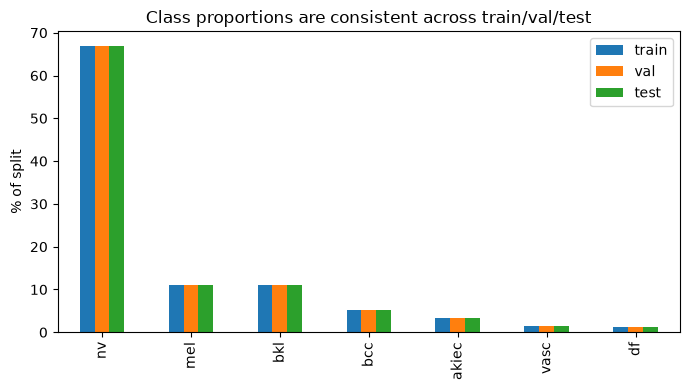

In [6]:
fig, ax = plt.subplots(figsize = (7, 4))
order = balance.sort_values('train', ascending = False).index
(balance.loc[order, ['train', 'val', 'test']]
    .div(balance.loc[order, ['train', 'val', 'test']].sum(axis = 0), axis = 1) * 100
).plot.bar(ax = ax)
ax.set_ylabel('% of split')
ax.set_title('Class proportions are consistent across train/val/test')
plt.tight_layout()
plt.savefig('outputs/class_balance.png', dpi = 120)
plt.show()

`nv` (melanocytic nevi - ordinary moles) is roughly two-thirds of every split. `df` and `vasc` are each barely more than 1%. Any model here has to actually learn the minority classes, or a shortcut of "always guess nv" will look deceptively good on overall accuracy alone - that's the trap the later notebooks specifically test for.

Example images, one row per class:

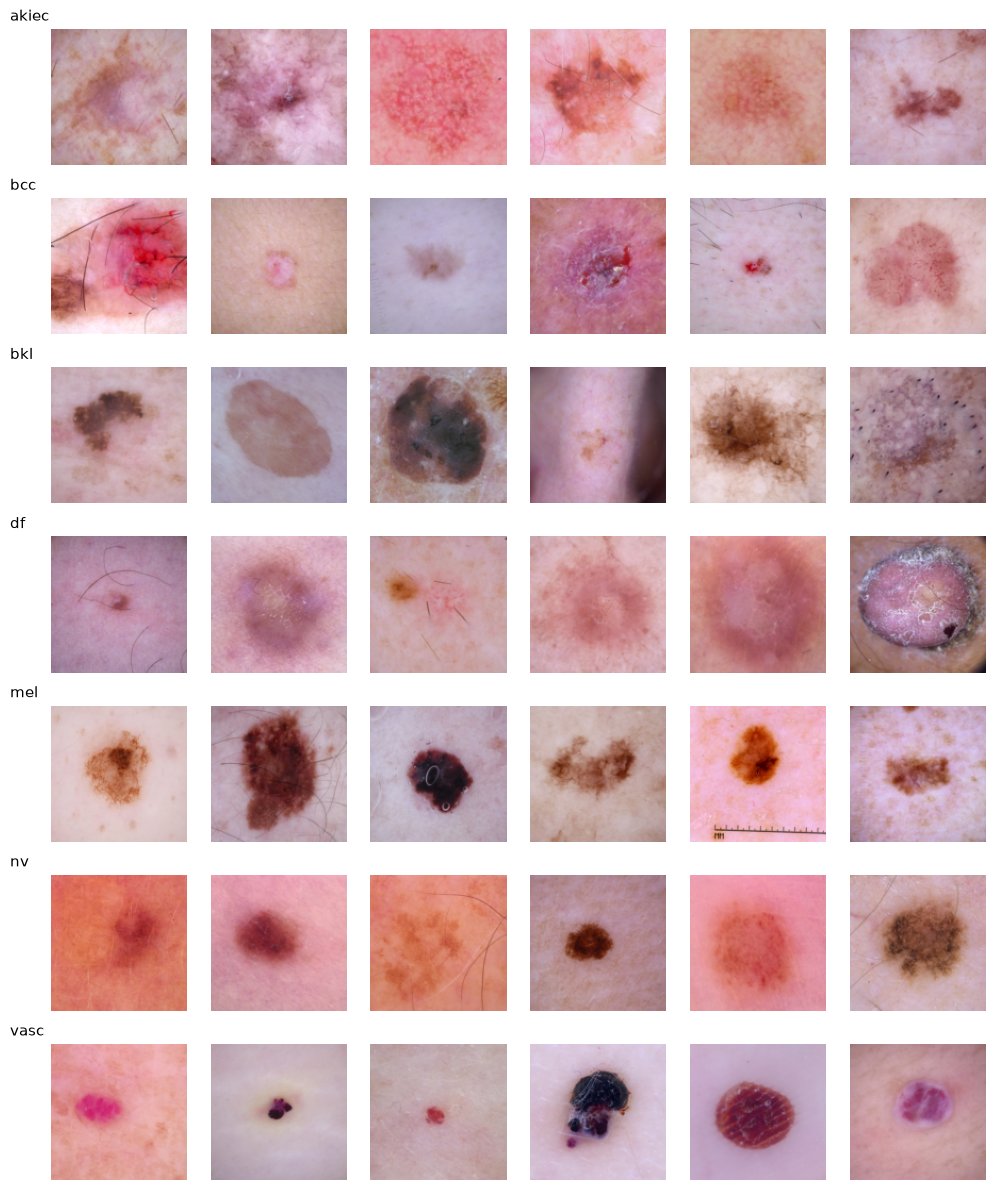

In [7]:
fig, axes = plt.subplots(7, 6, figsize = (10, 12))
for row, (label_idx, name) in enumerate(class_names.items()):
    idxs = np.where(train_labels == label_idx)[0][:6]
    for col in range(6):
        ax = axes[row, col]
        if col < len(idxs):
            ax.imshow(train_images[idxs[col]])
        ax.axis('off')
        if col == 0:
            ax.set_title(name, loc = 'left', fontsize = 11, x = -0.3)
plt.tight_layout()
plt.savefig('outputs/example_images.png', dpi = 120)
plt.show()

Demographic metadata from the Harvard Dataverse release - this covers all 10,015 source images (a superset of the 128x128 arrays above; DermaMNIST's official split doesn't preserve individual image IDs, so this is a dataset-level view rather than a per-image join).

In [8]:
meta = pd.read_csv(META_PATH, sep = '\t', quotechar = '"')
meta.shape

(10015, 8)

In [9]:
meta['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

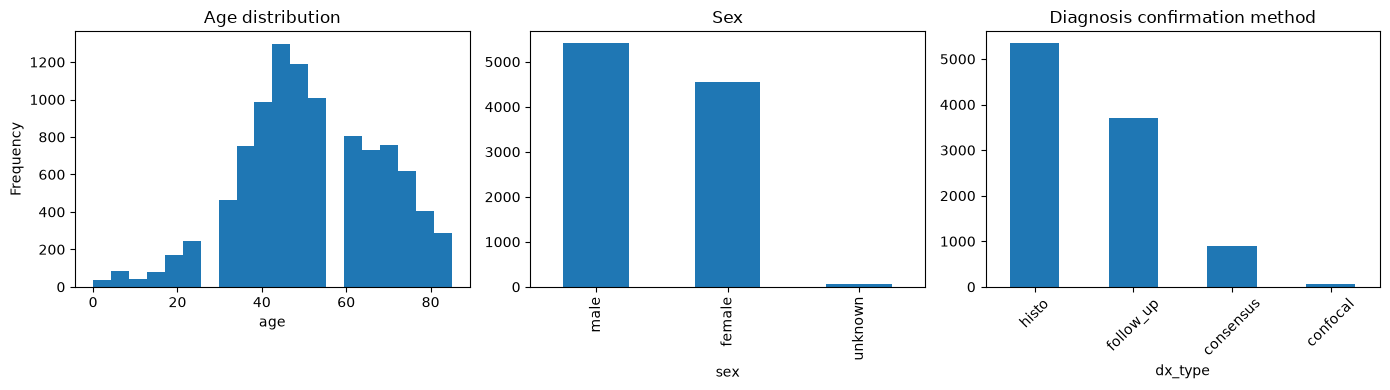

In [10]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4))

meta['age'].dropna().plot.hist(bins = 20, ax = axes[0])
axes[0].set_title('Age distribution')
axes[0].set_xlabel('age')

meta['sex'].value_counts().plot.bar(ax = axes[1])
axes[1].set_title('Sex')

meta['dx_type'].value_counts().plot.bar(ax = axes[2])
axes[2].set_title('Diagnosis confirmation method')
axes[2].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()
plt.savefig('outputs/demographics.png', dpi = 120)
plt.show()

In [11]:
meta['localization'].value_counts()

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

Most diagnoses are confirmed by histopathology (`histo`) - the reliable gold standard - though a meaningful share rely on follow-up or expert consensus instead. Back, lower extremity, and trunk are the most common lesion sites, which lines up with these being common sun-exposed or easily-photographed areas.

In [12]:
import json

summary = {
    'class_names': class_names,
    'split_sizes': {
        'train': int(len(train_labels)),
        'val': int(len(val_labels)),
        'test': int(len(test_labels)),
    },
    'class_balance_train_pct': balance['train_pct'].to_dict(),
    'image_shape': list(train_images.shape[1:]),
}
os.makedirs('outputs', exist_ok = True)
with open('outputs/data_summary.json', 'w') as f:
    json.dump(summary, f, indent = 2)

summary

{'class_names': {0: 'akiec',
  1: 'bcc',
  2: 'bkl',
  3: 'df',
  4: 'mel',
  5: 'nv',
  6: 'vasc'},
 'split_sizes': {'train': 7007, 'val': 1003, 'test': 2005},
 'class_balance_train_pct': {'nv': 67.0,
  'mel': 11.1,
  'bkl': 11.0,
  'bcc': 5.1,
  'akiec': 3.3,
  'vasc': 1.4,
  'df': 1.1},
 'image_shape': [128, 128, 3]}